# GLM Algorithm Arena — Phase 2: Multi-Dataset Benchmarking

Benchmarking of **all GLM solvers** across **real and synthetic datasets**
with a comprehensive, dataset-adaptive hyperparameter grid.

Each *(solver, config)* pair produces one coefficient vector β̂.
t-SNE and UMAP projections (on **unit-normalised** β̂) reveal how algorithmically
similar the solutions are across solver families.

Key features:
* **≥ 50 hyperparameter variations per solver** (lambda grids scaled to each
  dataset's natural scale; secondary parameters swept over representative grids).
* Larger, higher-dimensional datasets (p ≥ 30) where regularisation choices matter.
* Embedding plots coloured by **individual solver** (tab20, 20 distinct colours).


## Section 0 — Setup

In [1]:
import sys, os, time, warnings, itertools
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import (
    load_diabetes, load_breast_cancer, load_iris, load_wine,
    make_regression, make_classification, make_friedman1,
)
from sklearn.manifold import TSNE
import sklearn
import umap

print(f"sklearn  {sklearn.__version__}")
print(f"umap     {umap.__version__}")

_sk_ver = tuple(int(x) for x in sklearn.__version__.split('.')[:2])
_TSNE_ITER_KW = 'max_iter' if _sk_ver >= (1, 5) else 'n_iter'

# ── Solver imports ────────────────────────────────────────────────────────────
from src.glmzoo.solvers.classical.ols             import OLSSolver
from src.glmzoo.solvers.classical.ridge           import RidgeSolver
from src.glmzoo.solvers.classical.glm_irls        import GLMIRLSSolver
from src.glmzoo.solvers.penalized.lasso_cd        import LassoCDSolver
from src.glmzoo.solvers.penalized.elastic_net     import ElasticNetSolver
from src.glmzoo.solvers.penalized.adaptive_lasso  import AdaptiveLassoSolver
from src.glmzoo.solvers.penalized.scad_lla        import SCADLLASolver
from src.glmzoo.solvers.penalized.mcp_cd          import MCPCDSolver
from src.glmzoo.solvers.penalized.group_lasso     import GroupLassoSolver
from src.glmzoo.solvers.penalized.fused_lasso     import FusedLassoSolver
from src.glmzoo.solvers.path.lars                 import LARSSolver
from src.glmzoo.solvers.first_order.ista          import ISTASolver
from src.glmzoo.solvers.first_order.fista         import FISTASolver
from src.glmzoo.solvers.online.sgd                import SGDSolver
from src.glmzoo.solvers.online.implicit_sgd       import ImplicitSGDSolver
from src.glmzoo.solvers.online.adagrad            import AdaGradSolver
from src.glmzoo.solvers.online.fobos              import FOBOSSolver
from src.glmzoo.solvers.online.rda                import RDASolver
from src.glmzoo.solvers.online.truncated_gradient import TruncatedGradientSolver
from src.glmzoo.solvers.online.renewable_glm      import RenewableGLMSolver

print("All solver classes imported.")

# ── Family mapping ────────────────────────────────────────────────────────────
FAMILY = {
    OLSSolver: "Classical",           GLMIRLSSolver: "Classical",
    LARSSolver: "Classical",          RidgeSolver: "Penalized",
    LassoCDSolver: "Penalized",       ElasticNetSolver: "Penalized",
    AdaptiveLassoSolver: "Penalized", SCADLLASolver: "Penalized",
    MCPCDSolver: "Penalized",         GroupLassoSolver: "Penalized",
    FusedLassoSolver: "Penalized",    ISTASolver: "First-order",
    FISTASolver: "First-order",       SGDSolver: "Online",
    ImplicitSGDSolver: "Online",      AdaGradSolver: "Online",
    FOBOSSolver: "Online",            RDASolver: "Online",
    TruncatedGradientSolver: "Online", RenewableGLMSolver: "Online",
}

FAMILY_COLORS = {
    "Classical":   "#1f77b4",
    "Penalized":   "#2ca02c",
    "First-order": "#ff7f0e",
    "Online":      "#d62728",
}

# ── Per-solver colours (tab20, 20 distinct) ───────────────────────────────────
_SOLVER_ORDER = [
    OLSSolver, GLMIRLSSolver, LARSSolver,
    RidgeSolver, LassoCDSolver, ElasticNetSolver,
    AdaptiveLassoSolver, SCADLLASolver, MCPCDSolver,
    GroupLassoSolver, FusedLassoSolver,
    ISTASolver, FISTASolver,
    SGDSolver, ImplicitSGDSolver, AdaGradSolver,
    FOBOSSolver, RDASolver, TruncatedGradientSolver, RenewableGLMSolver,
]
ALGO_COLORS = {cls.__name__: plt.cm.tab20(i / 20) for i, cls in enumerate(_SOLVER_ORDER)}
ALGO_LABELS = {
    "OLSSolver":               "OLS",
    "GLMIRLSSolver":           "GLM-IRLS",
    "LARSSolver":              "LARS",
    "RidgeSolver":             "Ridge",
    "LassoCDSolver":           "Lasso-CD",
    "ElasticNetSolver":        "Elastic Net",
    "AdaptiveLassoSolver":     "Adaptive Lasso",
    "SCADLLASolver":           "SCAD",
    "MCPCDSolver":             "MCP-CD",
    "GroupLassoSolver":        "Group Lasso",
    "FusedLassoSolver":        "Fused Lasso",
    "ISTASolver":              "ISTA",
    "FISTASolver":             "FISTA",
    "SGDSolver":               "SGD",
    "ImplicitSGDSolver":       "Implicit SGD",
    "AdaGradSolver":           "AdaGrad",
    "FOBOSSolver":             "FOBOS",
    "RDASolver":               "RDA",
    "TruncatedGradientSolver": "Trunc. Grad.",
    "RenewableGLMSolver":      "Renewable GLM",
}


sklearn  1.8.0
umap     0.5.12
All solver classes imported.


## Section 1 — Load Datasets

In [2]:
RNG   = np.random.default_rng(42)
MAX_N = 2000
datasets = {}

def _add_regression(X, y, name):
    X = np.array(X, dtype=float); y = np.array(y, dtype=float)
    ok = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X, y = X[ok], y[ok]
    if len(X) < 50:
        print(f'  SKIP {name}: n={len(X)} < 50'); return
    if len(X) > MAX_N:
        idx = RNG.choice(len(X), MAX_N, replace=False); X, y = X[idx], y[idx]
    X = StandardScaler().fit_transform(X)
    y = (y - y.mean()) / (y.std() + 1e-12)
    datasets[name] = dict(X=X, y=y, link='identity', kind='regression')
    print(f'  [R] {name:40s}  n={X.shape[0]:5d}  p={X.shape[1]}')

def _add_logistic(X, y, name):
    X = np.array(X, dtype=float); y = np.array(y, dtype=float)
    ok = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X, y = X[ok], y[ok]
    if len(X) < 50:
        print(f'  SKIP {name}: n={len(X)} < 50'); return
    if len(X) > MAX_N:
        idx = RNG.choice(len(X), MAX_N, replace=False); X, y = X[idx], y[idx]
    X = StandardScaler().fit_transform(X)
    datasets[name] = dict(X=X, y=y, link='logit', kind='logistic')
    print(f'  [L] {name:40s}  n={X.shape[0]:5d}  p={X.shape[1]}')

# ── A. sklearn bundled ────────────────────────────────────────────────────────
print('sklearn built-ins:')
d = load_diabetes();      _add_regression(d.data, d.target, 'Diabetes')
d = load_breast_cancer(); _add_logistic(d.data, d.target.astype(float), 'Breast_Cancer')
# load_digits: n=1797, p=64 — much richer than Iris/Wine
from sklearn.datasets import load_digits
d = load_digits(); _add_logistic(d.data, (d.target >= 5).astype(float), 'Digits_hi5')

# ── B. statsmodels bundled ────────────────────────────────────────────────────
print('\nstatsmodels built-ins:')
try:
    import statsmodels.datasets as smd

    # fair: n=6366, p=9  (regression — large n)
    d = smd.fair.load_pandas().data
    _add_regression(d.drop(columns=['affairs']).select_dtypes(include=[float,'int64']).values,
                    d['affairs'].values, 'Fair_Affairs')

    # randhie: n=20190, p=10  (regression — very large n)
    d = smd.randhie.load_pandas().data.select_dtypes(include=[float,'int64']).dropna()
    yc = 'lnmeddol' if 'lnmeddol' in d.columns else d.columns[0]
    _add_regression(d.drop(columns=[yc]).values, d[yc].values, 'RAND_HIE')

    # star98: n=303, p=22 (logistic)
    d = smd.star98.load_pandas().data.select_dtypes(include=[float,'int64']).dropna()
    y0 = d.iloc[:,0].values; X0 = d.iloc[:,1:].values
    _add_logistic(X0, (y0 > np.median(y0)).astype(float), 'STAR98_pass')

    # anes96: n=944, p=11 (logistic)
    d = smd.anes96.load_pandas().data.select_dtypes(include=[float,'int64']).dropna()
    y0 = d.iloc[:,0].values; X0 = d.iloc[:,1:].values
    _add_logistic(X0, (y0 > np.median(y0)).astype(float), 'ANES96_vote')

    # modechoice: n=840, p=9 (logistic)
    d = smd.modechoice.load_pandas().data.select_dtypes(include=[float,'int64']).dropna()
    y0 = d.iloc[:,0].values; X0 = d.iloc[:,1:].values
    _add_logistic(X0, (y0 > np.median(y0)).astype(float), 'Mode_Choice')

except Exception as e:
    print(f'  statsmodels error: {e}')

# ── C. Synthetic — large n, high p so regularisation choices matter ───────────
# Goal: p >=50 so different solvers produce genuinely distinct beta patterns.
print('\nSynthetic (large, high-dimensional):')

# Sparse regression: only 20 of 200 features are informative
Xs, ys = make_regression(n_samples=2000, n_features=200, n_informative=20,
                          noise=0.5, random_state=1)
_add_regression(Xs, ys, 'Synth_Reg_Sparse200')

# Dense regression: all 100 features informative
Xs, ys = make_regression(n_samples=2000, n_features=100, n_informative=100,
                          noise=0.3, random_state=2)
_add_regression(Xs, ys, 'Synth_Reg_Dense100')

# Correlated regression: effective_rank=10 → strong multi-collinearity, p=150
Xs, ys = make_regression(n_samples=2000, n_features=150, n_informative=80,
                          effective_rank=10, noise=0.4, random_state=3)
_add_regression(Xs, ys, 'Synth_Reg_Corr150')

# Very high-dim sparse: p=300, only 30 informative
Xs, ys = make_regression(n_samples=2000, n_features=300, n_informative=30,
                          noise=1.0, random_state=4)
_add_regression(Xs, ys, 'Synth_Reg_HighDim300')

# Friedman1: non-linear ground truth, p=10 (keep as baseline)
Xs, ys = make_friedman1(n_samples=2000, n_features=10, noise=0.5, random_state=42)
_add_regression(Xs, ys, 'Synth_Friedman1')

# Dense logistic: p=100
Xs, ys = make_classification(n_samples=2000, n_features=100, n_informative=80,
                              n_redundant=15, random_state=5)
_add_logistic(Xs, ys.astype(float), 'Synth_Logit_Dense100')

# Sparse logistic: p=200, only 25 informative
Xs, ys = make_classification(n_samples=2000, n_features=200, n_informative=25,
                              n_redundant=50, random_state=6)
_add_logistic(Xs, ys.astype(float), 'Synth_Logit_Sparse200')

# Noisy logistic: p=150, label noise
Xs, ys = make_classification(n_samples=2000, n_features=150, n_informative=40,
                              n_redundant=40, flip_y=0.12, random_state=7)
_add_logistic(Xs, ys.astype(float), 'Synth_Logit_Noisy150')

print(f'\nTotal datasets loaded: {len(datasets)}')
for name, ds in datasets.items():
    print(f'  {name:40s}  n={ds["X"].shape[0]:5d}  p={ds["X"].shape[1]:4d}  {ds["kind"]}')


sklearn built-ins:
  [R] Diabetes                                  n=  442  p=10
  [L] Breast_Cancer                             n=  569  p=30
  [L] Digits_hi5                                n= 1797  p=64

statsmodels built-ins:
  [R] Fair_Affairs                              n= 2000  p=8
  [R] RAND_HIE                                  n= 2000  p=9
  [L] STAR98_pass                               n=  303  p=21
  [L] ANES96_vote                               n=  944  p=10
  [L] Mode_Choice                               n=  840  p=8

Synthetic (large, high-dimensional):
  [R] Synth_Reg_Sparse200                       n= 2000  p=200
  [R] Synth_Reg_Dense100                        n= 2000  p=100
  [R] Synth_Reg_Corr150                         n= 2000  p=150


  [R] Synth_Reg_HighDim300                      n= 2000  p=300
  [R] Synth_Friedman1                           n= 2000  p=10
  [L] Synth_Logit_Dense100                      n= 2000  p=100


  [L] Synth_Logit_Sparse200                     n= 2000  p=200
  [L] Synth_Logit_Noisy150                      n= 2000  p=150

Total datasets loaded: 16
  Diabetes                                  n=  442  p=  10  regression
  Breast_Cancer                             n=  569  p=  30  logistic
  Digits_hi5                                n= 1797  p=  64  logistic
  Fair_Affairs                              n= 2000  p=   8  regression
  RAND_HIE                                  n= 2000  p=   9  regression
  STAR98_pass                               n=  303  p=  21  logistic
  ANES96_vote                               n=  944  p=  10  logistic
  Mode_Choice                               n=  840  p=   8  logistic
  Synth_Reg_Sparse200                       n= 2000  p= 200  regression
  Synth_Reg_Dense100                        n= 2000  p= 100  regression
  Synth_Reg_Corr150                         n= 2000  p= 150  regression
  Synth_Reg_HighDim300                      n= 2000  p= 300  regr

## Section 2 — Adaptive Hyperparameter Grid

For every dataset we compute `lam_max = max|X'(y-ȳ)|/n` and generate lambda
grids as fractions of that value (range: `[0.001·λ_max, λ_max]`, wider than before).

| Solver | Configs | Strategy |
|---|---|---|
| Ridge, Lasso-CD, ISTA, FISTA, LARS | 50 | 50 log-spaced λ |
| Elastic Net | 50 | 10 λ × 5 α (l1-ratio) |
| Adaptive Lasso, SCAD, MCP | 50 | 10 λ × 5 secondary param |
| Group Lasso | 50 | 10 λ × 5 group configs |
| Fused Lasso | 56 | 7×8 (λ1, λ2) grid |
| SGD, Implicit SGD, AdaGrad | 50 | 5 step-size × 10 n_passes |
| FOBOS, RDA, Trunc. Grad. | 50 | 5 λ × 5 γ₀ × 2 K/passes |
| Renewable GLM | 50 | 5 n_batches × 10 ridge_init |


In [3]:
def compute_lam_max(X, y):
    return float(np.max(np.abs(X.T @ (y - y.mean()))) / len(y))

def make_groups(p, n_groups):
    n_groups = max(1, min(n_groups, p))
    return [list(range(j, p, n_groups)) for j in range(n_groups)]

def build_configs(lam_max, p, kind='regression'):
    '''≥ 50 (solver, config, label) triples per solver.'''
    cfgs = []

    # lambda grid: frac_min=0.001 gives a wide path from near-OLS to sparse
    def lam_grid(n=50, frac_min=0.001):
        lo = max(lam_max * frac_min, 1e-7)
        hi = max(lam_max, lo * 2)
        return np.logspace(np.log10(lo), np.log10(hi), n)

    cfgs.append((OLSSolver,     {}, 'OLS'))
    cfgs.append((GLMIRLSSolver, {}, 'IRLS'))

    if kind == 'regression':
        for lam in lam_grid(50): cfgs.append((LARSSolver, {'lam': float(lam)}, f'LARS λ={lam:.4g}'))

    for lam in lam_grid(50): cfgs.append((RidgeSolver,   {'lam': float(lam)}, f'Ridge λ={lam:.4g}'))
    for lam in lam_grid(50): cfgs.append((LassoCDSolver, {'lam': float(lam)}, f'Lasso λ={lam:.4g}'))
    for lam in lam_grid(50): cfgs.append((ISTASolver,    {'lam': float(lam)}, f'ISTA λ={lam:.4g}'))
    for lam in lam_grid(50): cfgs.append((FISTASolver,   {'lam': float(lam)}, f'FISTA λ={lam:.4g}'))

    for lam in lam_grid(10):
        for a in [0.1, 0.3, 0.5, 0.7, 0.9]:
            cfgs.append((ElasticNetSolver, {'lam': float(lam), 'alpha': a}, f'EN λ={lam:.4g} α={a}'))

    for lam in lam_grid(10):
        for g in [0.5, 1.0, 2.0, 3.0, 5.0]:
            cfgs.append((AdaptiveLassoSolver, {'lam': float(lam), 'gamma': g}, f'AdaLasso λ={lam:.4g} γ={g}'))

    for lam in lam_grid(10):
        for a in [2.5, 3.7, 5.0, 7.0, 10.0]:
            cfgs.append((SCADLLASolver, {'lam': float(lam), 'a': a}, f'SCAD λ={lam:.4g} a={a}'))

    for lam in lam_grid(10):
        for g in [1.5, 2.0, 3.0, 5.0, 8.0]:
            cfgs.append((MCPCDSolver, {'lam': float(lam), 'gamma': g}, f'MCP λ={lam:.4g} γ={g}'))

    ng_vals = sorted(set([2, max(2, p//10), max(2, p//5), max(2, p//3),
                          min(p, max(5, p//2))]))[:5]
    for lam in lam_grid(10):
        for ng in ng_vals:
            cfgs.append((GroupLassoSolver, {'lam': float(lam), 'groups': make_groups(p, ng)},
                         f'GrpLasso λ={lam:.4g} G={ng}'))

    if kind == 'regression':
        lf1 = lam_grid(7); lf2 = lam_grid(8)
        for l1, l2 in itertools.product(lf1, lf2):
            cfgs.append((FusedLassoSolver, {'lam1': float(l1), 'lam2': float(l2)},
                         f'Fused λ1={l1:.4g} λ2={l2:.4g}'))

    for g in [0.001, 0.005, 0.01, 0.05, 0.1]:
        for T in [5, 10, 20, 30, 50, 80, 100, 150, 200, 300]:
            cfgs.append((SGDSolver, {'gamma0': g, 'n_passes': T}, f'SGD γ={g} T={T}'))

    for g in [0.001, 0.005, 0.01, 0.05, 0.1]:
        for a in [0.51, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]:
            cfgs.append((ImplicitSGDSolver, {'gamma0': g, 'alpha': a, 'n_passes': 10},
                         f'ISGD γ={g} α={a}'))

    for e in [0.01, 0.05, 0.1, 0.5, 1.0]:
        for T in [5, 10, 20, 30, 50, 80, 100, 150, 200, 300]:
            cfgs.append((AdaGradSolver, {'eta': e, 'n_passes': T}, f'AdaGrad η={e} T={T}'))

    for lam in lam_grid(5):
        for g in [0.001, 0.01, 0.05, 0.1, 0.5]:
            for T in [10, 20]:
                cfgs.append((FOBOSSolver, {'lam': float(lam), 'gamma0': g, 'n_passes': T},
                             f'FOBOS λ={lam:.4g} γ={g} T={T}'))

    for lam in lam_grid(5):
        for g in [0.001, 0.01, 0.05, 0.1, 0.5]:
            for T in [5, 10]:
                cfgs.append((RDASolver, {'lam': float(lam), 'gamma0': g, 'n_passes': T},
                             f'RDA λ={lam:.4g} γ={g} T={T}'))

    for lam in lam_grid(5):
        for g in [0.001, 0.01, 0.05, 0.1, 0.5]:
            for K in [5, 10]:
                cfgs.append((TruncatedGradientSolver, {'lam': float(lam), 'gamma0': g, 'K': K},
                             f'TruncGrad λ={lam:.4g} γ={g} K={K}'))

    for nb_ in [3, 5, 10, 20, 50]:
        for ri in [1e-5, 1e-4, 1e-3, 1e-2, 5e-2, 0.1, 0.3, 1.0, 3.0, 10.0]:
            cfgs.append((RenewableGLMSolver, {'n_batches': nb_, 'ridge_init': ri},
                         f'Renew B={nb_} r={ri}'))

    return cfgs

print(f'Config builder defined.')
# quick count check
import sys; sys.path.insert(0, '..')
_dummy_lam = 0.1
_p_ex = 100
_cfgs_reg = build_configs(_dummy_lam, _p_ex, 'regression')
_cfgs_log = build_configs(_dummy_lam, _p_ex, 'logistic')
print(f'Example (p={_p_ex}):  regression={len(_cfgs_reg)} configs,  logistic={len(_cfgs_log)} configs')

# per-solver breakdown
from collections import Counter
reg_cnt = Counter(cls.__name__ for cls, _, __ in _cfgs_reg)
for solver, n in sorted(reg_cnt.items(), key=lambda x: -x[1]):
    print(f'  {ALGO_LABELS.get(solver, solver):22s}: {n} configs')


Config builder defined.
Example (p=100):  regression=908 configs,  logistic=802 configs
  Fused Lasso           : 56 configs
  LARS                  : 50 configs
  Ridge                 : 50 configs
  Lasso-CD              : 50 configs
  ISTA                  : 50 configs
  FISTA                 : 50 configs
  Elastic Net           : 50 configs
  Adaptive Lasso        : 50 configs
  SCAD                  : 50 configs
  MCP-CD                : 50 configs
  Group Lasso           : 50 configs
  SGD                   : 50 configs
  Implicit SGD          : 50 configs
  AdaGrad               : 50 configs
  FOBOS                 : 50 configs
  RDA                   : 50 configs
  Trunc. Grad.          : 50 configs
  Renewable GLM         : 50 configs
  OLS                   : 1 configs
  GLM-IRLS              : 1 configs


## Section 3 — Run Arena

In [4]:
SKIP_FOR_LOGISTIC = {LARSSolver, FusedLassoSolver}
records = []
t_arena = time.time()

for di, (ds_name, ds) in enumerate(datasets.items()):
    X, y, link, kind = ds['X'], ds['y'], ds['link'], ds['kind']
    n, p = X.shape
    lam_max      = compute_lam_max(X, y)
    solver_cfgs  = build_configs(lam_max, p, kind)
    t0 = time.time(); n_ok = 0
    for SolverCls, cfg, label in solver_cfgs:
        if kind == 'logistic' and SolverCls in SKIP_FOR_LOGISTIC:
            continue
        try:
            res  = SolverCls(config=cfg).fit(X, y, link=link)
            beta = res.beta_hat
            if not np.all(np.isfinite(beta)):
                raise ValueError('non-finite beta')
            records.append(dict(
                dataset=ds_name, kind=kind, label=label,
                cls=SolverCls.__name__, family=FAMILY[SolverCls],
                beta=beta.copy(), bnorm=float(np.linalg.norm(beta)),
                ok=True, p=p,
            ))
            n_ok += 1
        except Exception:
            records.append(dict(
                dataset=ds_name, kind=kind, label=label,
                cls=SolverCls.__name__, family=FAMILY.get(SolverCls, '?'),
                beta=None, bnorm=np.nan, ok=False, p=p,
            ))
    print(f"[{di+1:2d}/{len(datasets)}] {ds_name:35s}  "
          f"n={n:4d} p={p:3d}  cfgs={len(solver_cfgs):3d}  ok={n_ok:3d}  {time.time()-t0:.1f}s")

df_all = pd.DataFrame(records)
print(f"\nArena done in {time.time()-t_arena:.1f}s")
print(f"Total: {len(df_all)}  |  OK: {df_all.ok.sum()} ({100*df_all.ok.mean():.1f}%)")


OLS is defined for the identity link; performing one Newton step as an approximation for link='logit'.


RidgeSolver closed form is for the identity link; falling back to Gaussian (identity) fit for link='logit'.


RidgeSolver closed form is for the identity link; falling back to Gaussian (identity) fit for link='logit'.


RidgeSolver closed form is for the identity link; falling back to Gaussian (identity) fit for link='logit'.


RidgeSolver closed form is for the identity link; falling back to Gaussian (identity) fit for link='logit'.


...

GroupLassoSolver uses Gaussian fit for link='logit'.


GroupLassoSolver uses Gaussian fit for link='logit'.


GroupLassoSolver uses Gaussian fit for link='logit'.


GroupLassoSolver uses Gaussian fit for link='logit'.


[16/16] Synth_Logit_Noisy150                 n=2000 p=150  cfgs=802  ok=795  511.1s

Arena done in 2236.4s
Total: 13530  |  OK: 13415 (99.2%)


## Section 4 — Results Summary

In [5]:
print(df_all.groupby(['dataset','ok']).size().unstack(fill_value=0).to_string())
print()
print(df_all.groupby(['family','ok']).size().unstack(fill_value=0).to_string())


ok                     False  True 
dataset                            
ANES96_vote                0    782
Breast_Cancer             33    769
Diabetes                   8    880
Digits_hi5                15    787
Fair_Affairs               0    878
Mode_Choice                0    772
RAND_HIE                   0    888
STAR98_pass               23    769
Synth_Friedman1            0    888
Synth_Logit_Dense100       7    795
Synth_Logit_Noisy150       7    795
Synth_Logit_Sparse200     14    788
Synth_Reg_Corr150          8    900
Synth_Reg_Dense100         0    908
Synth_Reg_HighDim300       0    908
Synth_Reg_Sparse200        0    908

ok           False  True 
family                   
Classical        0    432
First-order      0   1600
Online           0   5600
Penalized      115   5783


## Section 5 — Outlier Filtering (30× median norm)

Remove only genuinely unstable runs (norm > 30× median).  A threshold of 5× was
too aggressive: it filtered out the unregularised OLS / LARS solutions which
have legitimately higher norms than the heavily-penalised configs, leaving only
near-zero betas in the embedding → all points collapsed to 1–2 dots.


In [6]:
def filter_outliers(df, thresh=30.0):
    parts = []
    for ds_name in df['dataset'].unique():
        g = df[(df['dataset'] == ds_name) & df['ok']].copy()
        if len(g) == 0: continue
        med = g['bnorm'].median(); med = med if med > 0 else 1.0
        mask  = g['bnorm'] <= thresh * med
        n_out = (~mask).sum()
        if n_out: print(f'  {ds_name}: {n_out} outliers removed (bnorm > {thresh:.0f}× median {med:.3f})')
        parts.append(g[mask])
    return pd.concat(parts, ignore_index=True)

df_clean = filter_outliers(df_all)
print(f'\nClean runs: {len(df_clean)}  across {df_clean["dataset"].nunique()} datasets')


  Diabetes: 15 outliers removed (bnorm > 30× median 0.529)
  Breast_Cancer: 22 outliers removed (bnorm > 30× median 1.050)
  Digits_hi5: 34 outliers removed (bnorm > 30× median 0.771)
  Fair_Affairs: 5 outliers removed (bnorm > 30× median 0.213)
  STAR98_pass: 26 outliers removed (bnorm > 30× median 1.190)
  ANES96_vote: 34 outliers removed (bnorm > 30× median 0.625)
  Mode_Choice: 9 outliers removed (bnorm > 30× median 0.175)
  Synth_Reg_Sparse200: 43 outliers removed (bnorm > 30× median 0.985)
  Synth_Reg_Dense100: 10 outliers removed (bnorm > 30× median 0.954)
  Synth_Reg_Corr150: 70 outliers removed (bnorm > 30× median 1.016)
  Synth_Reg_HighDim300: 59 outliers removed (bnorm > 30× median 1.000)
  Synth_Logit_Dense100: 35 outliers removed (bnorm > 30× median 0.726)
  Synth_Logit_Sparse200: 31 outliers removed (bnorm > 30× median 0.676)
  Synth_Logit_Noisy150: 37 outliers removed (bnorm > 30× median 0.670)

Clean runs: 12985  across 16 datasets


## Section 6 — Per-Dataset Embeddings: t-SNE and UMAP

Each point is one *(solver, config)* run.  **Colour = individual solver** (tab20,
20 distinct colours).  Centroid labels mark the cluster centre of each solver.


In [7]:
import glob as _glob, os as _os
from sklearn.decomposition import PCA

# ── Delete all old embedding plots so only new ones remain ───────────────────
_old_pngs = _glob.glob('fig_*.png')
for _f in _old_pngs:
    _os.remove(_f)
    print(f'  Deleted old plot: {_f}')
print(f'Removed {len(_old_pngs)} old plots.\n')

embed_figs = []

for ds_name, grp in df_clean.groupby('dataset'):
    n_pts = len(grp)
    if n_pts < 15:
        print(f'SKIP {ds_name}: only {n_pts} clean points'); continue

    p       = int(grp['p'].iloc[0])
    betas   = np.vstack(grp['beta'].values)
    cls_arr = grp['cls'].values

    # ── PCA pre-reduction (standard practice before t-SNE) ───────────────────
    n_pca = min(50, n_pts - 1, p)
    betas_pca = PCA(n_components=n_pca, random_state=42).fit_transform(betas)

    # t-SNE
    perp    = min(40, max(5, n_pts // 8))
    xy_tsne = TSNE(n_components=2, perplexity=perp, init='pca',
                   random_state=42, **{_TSNE_ITER_KW: 1500}).fit_transform(betas_pca)
    # UMAP
    nn      = min(30, max(5, n_pts // 8))
    xy_umap = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.05,
                        random_state=42).fit_transform(betas_pca)

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    fig.patch.set_facecolor('#f5f5f5')
    ds_meta = datasets[ds_name]
    fig.suptitle(
        f"{ds_name}  ·  n={ds_meta['X'].shape[0]}, p={p}, {ds_meta['kind']}"
        f"  ·  {n_pts} (solver × config) points  [raw β̂]",
        fontsize=13, fontweight='bold', y=1.005,
    )

    present_cls = [c for c in [s.__name__ for s in _SOLVER_ORDER] if c in cls_arr]

    for ax, coords, method in zip(axes, [xy_tsne, xy_umap], ['t-SNE', 'UMAP']):
        ax.set_facecolor('#fafafa')
        for cls_name in present_cls:
            m = cls_arr == cls_name
            if m.sum() == 0: continue
            ax.scatter(coords[m,0], coords[m,1],
                       c=[ALGO_COLORS[cls_name]],
                       label=ALGO_LABELS.get(cls_name, cls_name),
                       alpha=0.65, s=40, linewidths=0, zorder=3)
        for cls_name in present_cls:
            m = cls_arr == cls_name
            if m.sum() < 3: continue
            cx, cy = coords[m,0].mean(), coords[m,1].mean()
            ax.annotate(ALGO_LABELS.get(cls_name, cls_name), (cx, cy),
                        ha='center', va='center', fontsize=6, fontweight='bold',
                        color=ALGO_COLORS[cls_name],
                        bbox=dict(boxstyle='round,pad=0.18', fc='white', alpha=0.82, ec='none'),
                        zorder=5)
        ax.set_title(method, fontsize=13, pad=10, fontweight='semibold')
        ax.set_xlabel(f'{method} 1', fontsize=9, color='#555')
        ax.set_ylabel(f'{method} 2', fontsize=9, color='#555')
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for sp in ax.spines.values(): sp.set_visible(False)

    handles = [mpatches.Patch(color=ALGO_COLORS[c], label=ALGO_LABELS.get(c, c))
               for c in present_cls]
    axes[1].legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1.0),
                   framealpha=0.92, fontsize=8.5, title='Solver', title_fontsize=9,
                   borderpad=0.7, labelspacing=0.35, edgecolor='#ccc')

    plt.tight_layout()
    safe  = (ds_name.replace(' ','_').replace('/','_')
             .replace('(','').replace(')','').replace('-','_'))
    fname = f'fig_embed_{safe}.png'
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.close(fig)
    embed_figs.append(fname)
    print(f'  Saved: {fname}')

print(f'\nTotal embedding figures: {len(embed_figs)}')


  Deleted old plot: fig_embed_ANES96_vote.png
  Deleted old plot: fig_embed_Breast_Cancer.png
  Deleted old plot: fig_embed_Diabetes.png
  Deleted old plot: fig_embed_Digits_hi5.png
  Deleted old plot: fig_embed_Fair_Affairs.png
  Deleted old plot: fig_embed_Mode_Choice.png
  Deleted old plot: fig_embed_RAND_HIE.png
  Deleted old plot: fig_embed_STAR98_pass.png
  Deleted old plot: fig_embed_Synth_Friedman1.png
  Deleted old plot: fig_embed_Synth_Logit_Dense100.png
  Deleted old plot: fig_embed_Synth_Logit_Noisy150.png
  Deleted old plot: fig_embed_Synth_Logit_Sparse200.png
  Deleted old plot: fig_embed_Synth_Reg_Corr150.png
  Deleted old plot: fig_embed_Synth_Reg_Dense100.png
  Deleted old plot: fig_embed_Synth_Reg_HighDim300.png
  Deleted old plot: fig_embed_Synth_Reg_Sparse200.png
  Deleted old plot: fig_heatmap_ANES96_vote.png
  Deleted old plot: fig_heatmap_Breast_Cancer.png
  Deleted old plot: fig_heatmap_Diabetes.png
  Deleted old plot: fig_heatmap_Digits_hi5.png
  Deleted old pl

  Saved: fig_embed_ANES96_vote.png


  Saved: fig_embed_Breast_Cancer.png


  Saved: fig_embed_Diabetes.png


  Saved: fig_embed_Digits_hi5.png


...

  Saved: fig_embed_Synth_Logit_Sparse200.png


  Saved: fig_embed_Synth_Reg_Corr150.png


  Saved: fig_embed_Synth_Reg_Dense100.png


  Saved: fig_embed_Synth_Reg_HighDim300.png


  Saved: fig_embed_Synth_Reg_Sparse200.png

Total embedding figures: 16


## Section 6b — Per-Dataset β Coefficient Heatmaps

Each figure shows **all (solver × config) runs** for one dataset as a heatmap:

* **Rows**: one row per successful run, sorted by solver family then solver name.
* **Columns**: β̂ feature dimensions (j = 0 … p−1).
* **Colour**: diverging `RdBu_r` centred at 0; scale set to the 99th percentile of
  |β̂| so outlier values don't dominate.
* **Left strip**: thin coloured bar whose colour matches the solver's tab20 colour,
  with y-tick labels at each solver block's midpoint.
* **Top strip**: per-feature mean |β̂| across all runs, showing which features are
  most consistently used by any solver.

High-p datasets (p ≥ 100) show patterns of sparsity, grouping, and smoothness
that distinguish penalised families clearly.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 6b — β Coefficient Heatmaps
# ─────────────────────────────────────────────────────────────────────────────
heatmap_figs = []

# Sort order: family priority, then solver name, then bnorm
_FAM_ORDER = {'Classical': 0, 'Penalized': 1, 'First-order': 2, 'Online': 3}

for ds_name, grp in df_clean.groupby('dataset'):
    n_pts = len(grp)
    if n_pts < 10:
        print(f'SKIP {ds_name}: only {n_pts} clean points'); continue

    # Sort rows: family → solver name → bnorm
    grp2 = grp.copy()
    grp2['_fam_ord'] = grp2['family'].map(_FAM_ORDER).fillna(9)
    grp2 = grp2.sort_values(['_fam_ord', 'cls', 'bnorm']).reset_index(drop=True)

    betas   = np.vstack(grp2['beta'].values)   # (n_runs, p)
    cls_arr = grp2['cls'].values
    n_runs, p = betas.shape

    # Symmetric colour scale (robust to outliers)
    vmax = float(np.percentile(np.abs(betas), 99))
    vmax = max(vmax, 1e-6)

    # ── Figure layout ────────────────────────────────────────────────────────
    # Width: left strip (0.6 in) + heatmap (depends on p) + colorbar (0.4 in)
    heatmap_w = max(10, min(p * 0.06 + 2, 28))   # cap at 28 in
    row_h     = max(8,  min(n_runs * 0.018 + 1, 24))  # cap at 24 in
    top_strip_h = 1.2  # inches for mean-|β| bar

    fig = plt.figure(figsize=(heatmap_w + 1.2, row_h + top_strip_h + 0.8))
    fig.patch.set_facecolor('#f5f5f5')

    # GridSpec: top row = mean-|β| bar, bottom row = [strip | heatmap]
    from matplotlib.gridspec import GridSpec
    gs = GridSpec(
        2, 2,
        height_ratios=[top_strip_h, row_h],
        width_ratios=[0.6, heatmap_w],
        hspace=0.04, wspace=0.01,
        left=0.10, right=0.88, top=0.94, bottom=0.04,
    )
    ax_topblank = fig.add_subplot(gs[0, 0])   # blank corner
    ax_top      = fig.add_subplot(gs[0, 1])   # mean |β| bar
    ax_strip    = fig.add_subplot(gs[1, 0])   # solver-colour strip
    ax_heat     = fig.add_subplot(gs[1, 1])   # main heatmap

    ax_topblank.axis('off')

    # ── Top: per-feature mean |β| ─────────────────────────────────────────
    mean_abs = np.mean(np.abs(betas), axis=0)   # (p,)
    ax_top.bar(np.arange(p), mean_abs, color='#444', width=1.0, alpha=0.75)
    ax_top.set_xlim(-0.5, p - 0.5)
    ax_top.set_ylabel('mean|β|', fontsize=8, color='#333')
    ax_top.tick_params(left=True, bottom=False, labelleft=True, labelbottom=False,
                       labelsize=7)
    ax_top.set_facecolor('#fafafa')
    for sp in ax_top.spines.values(): sp.set_visible(False)
    ax_top.set_title(
        f'{ds_name}  ·  n={datasets[ds_name]["X"].shape[0]}, p={p},'
        f' {datasets[ds_name]["kind"]}  ·  {n_runs} runs'
        '  (rows sorted by solver family → solver → ‖β̂‖)',
        fontsize=11, fontweight='bold', pad=6,
    )

    # ── Left: solver-colour strip + y-tick labels ────────────────────────
    # Build RGBA strip (n_runs × 1 × 4)
    strip_rgba = np.array([ALGO_COLORS[c] for c in cls_arr]).reshape(n_runs, 1, 4)
    ax_strip.imshow(strip_rgba, aspect='auto', interpolation='nearest')
    ax_strip.set_xlim(-0.5, 0.5)
    ax_strip.set_ylim(n_runs - 0.5, -0.5)  # top-down

    # y-ticks: midpoint of each solver block
    _yticks, _ylabels = [], []
    unique_cls, counts = np.unique(cls_arr, return_counts=True)
    pos = 0
    for cls_name, cnt in zip(
        [c for c in [s.__name__ for s in _SOLVER_ORDER] if c in unique_cls],
        [counts[list(unique_cls).index(c)] for c in
         [c for c in [s.__name__ for s in _SOLVER_ORDER] if c in unique_cls]]
    ):
        mid = pos + cnt / 2.0
        _yticks.append(mid)
        _ylabels.append(ALGO_LABELS.get(cls_name, cls_name))
        pos += cnt

    ax_strip.set_yticks(_yticks)
    ax_strip.set_yticklabels(_ylabels, fontsize=7.5)
    ax_strip.tick_params(left=False, bottom=False, right=False,
                         labelleft=True, labelbottom=False)
    ax_strip.set_xticks([])
    for sp in ax_strip.spines.values(): sp.set_visible(False)
    ax_strip.set_facecolor('#fafafa')

    # ── Main heatmap ──────────────────────────────────────────────────────
    im = ax_heat.imshow(
        betas, aspect='auto', cmap='RdBu_r',
        vmin=-vmax, vmax=vmax, interpolation='nearest',
    )
    ax_heat.set_xlim(-0.5, p - 0.5)
    ax_heat.set_ylim(n_runs - 0.5, -0.5)
    ax_heat.set_yticks([])

    # x-ticks: every feature if p<=30, else sparse
    step = max(1, p // 20)
    xticks = list(range(0, p, step))
    ax_heat.set_xticks(xticks)
    ax_heat.set_xticklabels([str(j) for j in xticks], fontsize=7, rotation=0)
    ax_heat.set_xlabel('Feature index j', fontsize=9, color='#444')
    for sp in ax_heat.spines.values(): sp.set_visible(False)
    ax_heat.set_facecolor('#fafafa')

    # Horizontal separator lines between solver groups
    pos = 0
    for cls_name in [c for c in [s.__name__ for s in _SOLVER_ORDER] if c in cls_arr]:
        cnt = (cls_arr == cls_name).sum()
        if pos > 0:
            ax_heat.axhline(pos - 0.5, color='white', lw=0.6, alpha=0.7, zorder=4)
        pos += cnt

    # Colorbar
    cbar_ax = fig.add_axes([0.895, gs.bottom, 0.012, gs.top - gs.bottom - top_strip_h/(row_h+top_strip_h)*0.7])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_label('β̂ value', fontsize=8, color='#444')
    cb.ax.tick_params(labelsize=7)

    safe  = (ds_name.replace(' ','_').replace('/','_')
             .replace('(','').replace(')','').replace('-','_'))
    fname = f'fig_heatmap_{safe}.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    plt.close(fig)
    heatmap_figs.append(fname)
    print(f'  Saved: {fname}  ({n_runs} rows × {p} cols)')

print(f'\nTotal heatmap figures: {len(heatmap_figs)}')


  Saved: fig_heatmap_ANES96_vote.png  (748 rows × 10 cols)


  Saved: fig_heatmap_Breast_Cancer.png  (747 rows × 30 cols)


  Saved: fig_heatmap_Diabetes.png  (865 rows × 10 cols)


  Saved: fig_heatmap_Digits_hi5.png  (753 rows × 64 cols)


  Saved: fig_heatmap_Fair_Affairs.png  (873 rows × 8 cols)


...

  Saved: fig_heatmap_Synth_Logit_Sparse200.png  (757 rows × 200 cols)


  Saved: fig_heatmap_Synth_Reg_Corr150.png  (830 rows × 150 cols)


  Saved: fig_heatmap_Synth_Reg_Dense100.png  (898 rows × 100 cols)


  Saved: fig_heatmap_Synth_Reg_HighDim300.png  (849 rows × 300 cols)


  Saved: fig_heatmap_Synth_Reg_Sparse200.png  (865 rows × 200 cols)

Total heatmap figures: 16


## Section 7 — Coefficient Norm by Solver Family

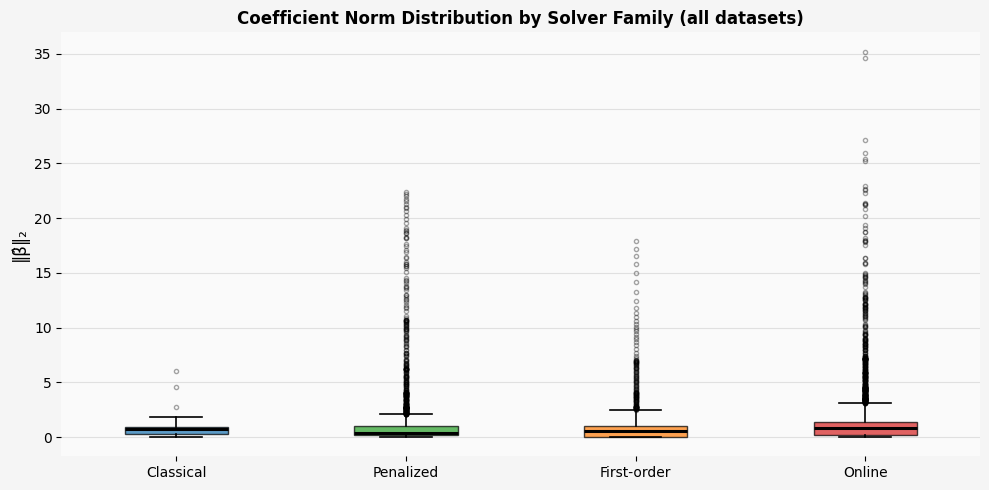

Saved: fig_norm_boxplot.png


In [9]:
fam_order = ['Classical', 'Penalized', 'First-order', 'Online']
data_bp   = [df_clean[df_clean['family'] == f]['bnorm'].dropna().values for f in fam_order]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#f5f5f5'); ax.set_facecolor('#fafafa')
bp = ax.boxplot(data_bp, labels=fam_order, patch_artist=True, notch=False,
                medianprops=dict(color='k', lw=2.2),
                whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.35))
for patch, fam in zip(bp['boxes'], fam_order):
    patch.set_facecolor(FAMILY_COLORS[fam]); patch.set_alpha(0.72)
ax.set_ylabel('‖β̂‖₂', fontsize=12)
ax.set_title('Coefficient Norm Distribution by Solver Family (all datasets)',
             fontsize=12, fontweight='semibold')
ax.grid(axis='y', alpha=0.35, zorder=0)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig('fig_norm_boxplot.png', dpi=110, bbox_inches='tight')
plt.show()
print("Saved: fig_norm_boxplot.png")


## Section 8 — Summary

In [10]:
print(f"Datasets loaded:      {len(datasets)}")
print(f"Total arena runs:     {len(df_all)}")
print(f"After outlier filter: {len(df_clean)}")
print()
print("Success rate by family:")
for fam in ['Classical', 'Penalized', 'First-order', 'Online']:
    sub = df_all[df_all['family'] == fam]
    if len(sub) == 0: continue
    print(f"  {fam:12s}: {sub['ok'].sum():5d}/{len(sub):5d}  ({100*sub['ok'].mean():.1f}%)")
print()
print("Mean ‖β̂‖₂ after filtering:")
for fam in ['Classical', 'Penalized', 'First-order', 'Online']:
    sub = df_clean[df_clean['family'] == fam]['bnorm']
    if len(sub) == 0: continue
    print(f"  {fam:12s}: mean={sub.mean():.4f}  median={sub.median():.4f}")
print()
print("Solver config counts (median per dataset):")
for cls in _SOLVER_ORDER:
    n_cfg = df_all[df_all['cls'] == cls.__name__].groupby('dataset')['label'].nunique().median()
    print(f"  {ALGO_LABELS[cls.__name__]:20s}: ~{n_cfg:.0f} configs/dataset")


Datasets loaded:      16
Total arena runs:     13530
After outlier filter: 12985

Success rate by family:
  Classical   :   432/  432  (100.0%)
  Penalized   :  5783/ 5898  (98.1%)
  First-order :  1600/ 1600  (100.0%)
  Online      :  5600/ 5600  (100.0%)

Mean ‖β̂‖₂ after filtering:
  Classical   : mean=0.6507  median=0.6974
  Penalized   : mean=0.9079  median=0.4097
  First-order : mean=0.9749  median=0.5156
  Online      : mean=1.3561  median=0.8409

Solver config counts (median per dataset):
  OLS                 : ~1 configs/dataset
  GLM-IRLS            : ~1 configs/dataset
  LARS                : ~50 configs/dataset
  Ridge               : ~50 configs/dataset
  Lasso-CD            : ~50 configs/dataset
  Elastic Net         : ~50 configs/dataset
  Adaptive Lasso      : ~50 configs/dataset
  SCAD                : ~50 configs/dataset
  MCP-CD              : ~50 configs/dataset
  Group Lasso         : ~50 configs/dataset
  Fused Lasso         : ~56 configs/dataset
  ISTA          